# Convolutional Neural Networks: From Pixels to Predictions

This notebook develops CNN intuition by repeatedly following the same loop:

> **predict the result → calculate it → verify it with PyTorch → visualize it**

It is designed to run end-to-end on a CPU without downloading a dataset.

## Learning objectives

By the end, you should be able to:

- interpret image and feature-map tensor shapes;
- calculate convolution and pooling outputs by hand;
- reason about kernel size, stride, padding, dilation, channels, parameters, and receptive fields;
- build, train, and inspect a small CNN;
- explain 1×1, depthwise-separable, inverted-residual, and transposed convolutions;
- recognize common misconceptions and implementation pitfalls.

**Prerequisites:** Python, arrays, and the basic idea of gradient-based neural-network training.


## Road map

1. [Setup](#setup)
2. [Images are tensors](#images-are-tensors)
3. [Convolution from first principles](#convolution-from-first-principles)
4. [Output geometry](#output-geometry)
   - [4.1 Dilation](#dilation)
5. [Channels, filters, and parameter counts](#channels-filters-and-parameter-counts)
6. [Activations and feature maps](#activations-and-feature-maps)
7. [Pooling](#pooling)
8. [Receptive fields](#receptive-fields)
9. [Train a small CNN](#train-a-small-cnn)
10. [Inspect learned representations](#inspect-learned-representations)
11. [Efficient convolutions](#efficient-convolutions)
12. [MobileNetV2 inverted residuals](#mobilenetv2-inverted-residuals)
13. [Transposed convolution](#transposed-convolution)
14. [Summary and exercises](#summary-and-exercises)


<a id="setup"></a>
## 1. Setup

The random seeds make the generated data and training run reproducible. PyTorch may still show very small numerical differences across hardware.


In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.figsize": (7, 4), "image.cmap": "gray"})

print(f"PyTorch: {torch.__version__}")
print(f"Device:  {device}")


PyTorch: 2.4.0+cu121
Device:  cuda


<a id="images-are-tensors"></a>
## 2. Images are tensors

A grayscale image is a grid of intensities with shape `(height, width)`. A color image normally has three channels—red, green, and blue. PyTorch convolution layers expect a batch in **NCHW** order:

$$
(N, C, H, W) = (	ext{batch},\ 	ext{channels},\ 	ext{height},\ 	ext{width}).
$$

Individual feature maps are not necessarily visible colors. After the first layer, a channel represents the response of a learned detector.


Single image (C, H, W): (3, 32, 32)
One-image batch (N, C, H, W): (1, 3, 32, 32)


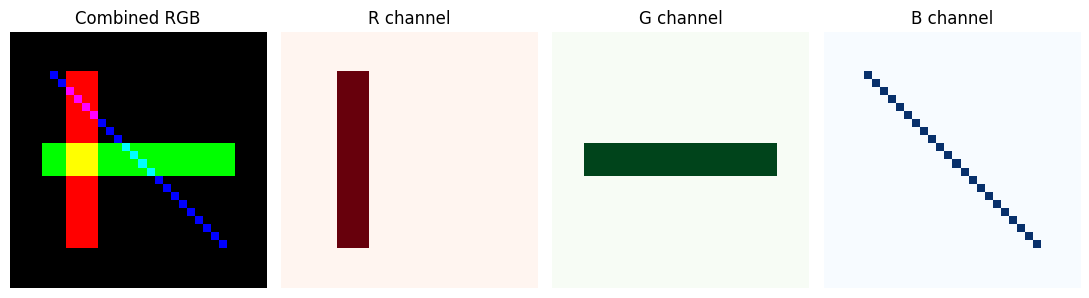

In [2]:
# Construct a tiny RGB image without external files.
rgb = torch.zeros(3, 32, 32)
rgb[0, 5:27, 7:11] = 1.0                    # red vertical bar
rgb[1, 14:18, 4:28] = 1.0                  # green horizontal bar
indices = torch.arange(5, 27)
rgb[2, indices, indices] = 1.0              # blue diagonal

batch = rgb.unsqueeze(0)
print("Single image (C, H, W):", tuple(rgb.shape))
print("One-image batch (N, C, H, W):", tuple(batch.shape))

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(rgb.permute(1, 2, 0))
axes[0].set_title("Combined RGB")
for channel, (name, color_map) in enumerate(zip("RGB", ["Reds", "Greens", "Blues"])):
    axes[channel + 1].imshow(rgb[channel], cmap=color_map, vmin=0, vmax=1)
    axes[channel + 1].set_title(f"{name} channel")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


<a id="convolution-from-first-principles"></a>
## 3. Convolution from first principles

A convolutional layer builds an output **feature map** by sliding a small matrix, called a **kernel** (or filter), across an image. At every location it performs the same three steps:

1. Select the image patch currently covered by the kernel.
2. Multiply the patch and kernel **element by element**. This is not matrix multiplication.
3. Sum all the products to produce one number in the output feature map.

For a 2D input $X$ and kernel $K$, the calculation at output position $(i,j)$ is

$$
Y[i,j] = \sum_{m=0}^{k_h-1}\sum_{n=0}^{k_w-1} X[i+m,j+n]K[m,n].
$$

Here, $(i,j)$ is the top-left corner of the current image patch, while $(m,n)$ moves through the kernel's $k_h$ rows and $k_w$ columns. Thus $X[i+m,j+n]$ and $K[m,n]$ refer to entries in matching positions. This sliding dot product is called **cross-correlation**. It is unrelated to the statistical correlation coefficient.

### Reading the example kernel

The kernel below has $+1$ in its left column, $0$ in its middle column, and $-1$ in its right column. Its output is therefore

$$
\text{sum of the patch's left column} - \text{sum of its right column}.
$$

A value near zero means the two sides are similar. A large positive or negative value indicates a strong left-to-right intensity change: a **vertical edge**. The sign records the direction of that change.

For the first $3\times3$ patch, the calculation is

$$
(3+5+1) - (1+2+3) = 9-6 = 3.
$$

The kernel then moves one column at a time and one row at a time. With no padding and stride 1, a $3\times3$ kernel has three valid horizontal and three valid vertical positions in a $5\times5$ image, so the output has shape $3\times3$.

### Why PyTorch calls this convolution

In classical signal processing, **convolution** flips the kernel horizontally and vertically before sliding it across the input. Cross-correlation uses the kernel exactly as written:

$$
\operatorname{convolution}(X,K) = \operatorname{cross\text{-}correlation}(X,\operatorname{flip}(K)).
$$

PyTorch's `conv2d`—like most deep-learning libraries—actually performs cross-correlation. The conventional name is harmless for learned filters: if a flipped pattern is useful, the network can learn the flipped weights directly.

The implementation below makes the sliding-window calculation explicit. It is deliberately slow and is intended for understanding rather than production. The following cell then verifies that its result matches `torch.nn.functional.conv2d`.


In [3]:
image = torch.tensor([
    [3., 4., 1., 2., 5.],
    [5., 6., 2., 1., 3.],
    [1., 2., 3., 4., 6.],
    [6., 7., 5., 4., 2.],
    [3., 2., 1., 6., 5.],
])
vertical_edge_kernel = torch.tensor([
    [1., 0., -1.],
    [1., 0., -1.],
    [1., 0., -1.],
])

def cross_correlation2d(x, kernel):
    # Valid, stride-1 cross-correlation for two 2D tensors.
    out_h = x.shape[0] - kernel.shape[0] + 1
    out_w = x.shape[1] - kernel.shape[1] + 1
    result = torch.empty(out_h, out_w)
    for row in range(out_h):
        for col in range(out_w):
            patch = x[row:row + kernel.shape[0], col:col + kernel.shape[1]]
            result[row, col] = (patch * kernel).sum()
    return result

first_patch = image[:3, :3]
manual_first_value = (first_patch * vertical_edge_kernel).sum()
manual_output = cross_correlation2d(image, vertical_edge_kernel)

print("First image patch:\n", first_patch)
print("First output = sum(patch × kernel) =", manual_first_value.item())
print("Complete output:\n", manual_output)


First image patch:
 tensor([[3., 4., 1.],
        [5., 6., 2.],
        [1., 2., 3.]])
First output = sum(patch × kernel) = 3.0
Complete output:
 tensor([[ 3.,  5., -8.],
        [ 2.,  6., -1.],
        [ 1., -3., -4.]])


Manual and PyTorch results match: True


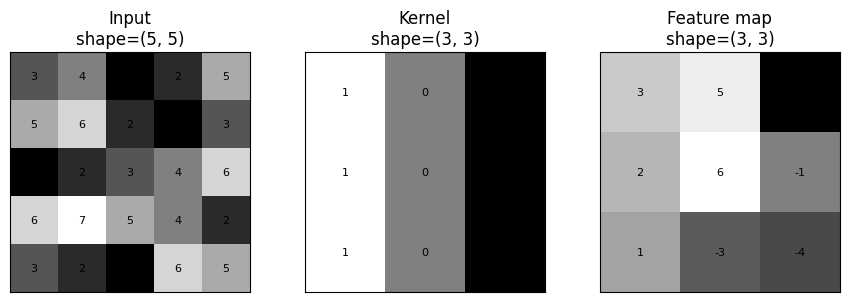

In [4]:
# PyTorch adds batch and channel dimensions: (H, W) -> (1, 1, H, W).
torch_output = F.conv2d(
    image[None, None],
    vertical_edge_kernel[None, None],
)[0, 0]

torch.testing.assert_close(manual_output, torch_output)
print("Manual and PyTorch results match:", torch.equal(manual_output, torch_output))

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, data, title in zip(
    axes,
    [image, vertical_edge_kernel, manual_output],
    ["Input", "Kernel", "Feature map"],
):
    shown = ax.imshow(data)
    ax.set_title(f"{title}\nshape={tuple(data.shape)}")
    ax.set_xticks([]); ax.set_yticks([])
    for (row, col), value in np.ndenumerate(data.numpy()):
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


<a id="output-geometry"></a>
## 4. Output geometry

For either spatial dimension, the output size of a convolution is

$$
\text{out}=\left\lfloor
\frac{\text{in}+2p-d(k-1)-1}{s}+1
\right\rfloor,
$$

where $k$ is kernel size, $s$ stride, $p$ padding, and $d$ dilation.

### Simplified formula when dilation is 1

Many introductory explanations assume an undilated kernel, so $d=1$. In that case the kernel's effective size is

$$
d(k-1)+1 = 1(k-1)+1 = k.
$$

Substituting $d=1$ into the general formula gives

$$
\text{out}=\left\lfloor\frac{\text{in}+2p-k}{s}+1\right\rfloor.
$$

For a square input of size $n\times n$ and a square kernel of size $f\times f$, this is often written as

$$
O=\left\lfloor\frac{n-f+2p}{s}+1\right\rfloor.
$$

We can also derive this by counting valid starting positions along one dimension. Padding makes the available input length $n+2p$. A kernel of length $f$ can move at most $n+2p-f$ positions away from its first position. With stride $s$, the number of complete moves is $\left\lfloor(n+2p-f)/s\right\rfloor$. Adding 1 counts the initial position, producing the formula above.

The floor is sometimes omitted in simplified presentations when $n-f+2p$ is known to be divisible by $s$. In the general case it is required because an output dimension must be an integer and a final partial kernel placement is not counted.

- **Stride** controls how far the kernel moves.
- **Padding** supplies values outside the original boundary (usually zeros).
- **Dilation** spaces kernel elements apart, increasing coverage without adding weights.
- “Valid” usually means no padding. “Same” aims to preserve spatial size for stride 1; exact conventions can vary when stride is greater than 1 or the kernel is even.

Apply the formula independently to height and width. The floor matters whenever the final step does not fit exactly.


In [5]:
def pair(value):
    return value if isinstance(value, tuple) else (value, value)

def conv2d_output_shape(input_hw, kernel_size, stride=1, padding=0, dilation=1):
    input_h, input_w = pair(input_hw)
    kernel_h, kernel_w = pair(kernel_size)
    stride_h, stride_w = pair(stride)
    pad_h, pad_w = pair(padding)
    dilation_h, dilation_w = pair(dilation)
    output_h = math.floor((input_h + 2 * pad_h - dilation_h * (kernel_h - 1) - 1) / stride_h + 1)
    output_w = math.floor((input_w + 2 * pad_w - dilation_w * (kernel_w - 1) - 1) / stride_w + 1)
    return output_h, output_w

examples = [
    {"input_hw": (32, 32), "kernel_size": 5, "stride": 1, "padding": 0},
    {"input_hw": (32, 32), "kernel_size": 5, "stride": 1, "padding": 2},
    {"input_hw": (31, 29), "kernel_size": 3, "stride": 2, "padding": 1},
    {"input_hw": (32, 32), "kernel_size": 3, "stride": 1, "padding": 2, "dilation": 2},
]

for settings in examples:
    predicted = conv2d_output_shape(**settings)
    layer = nn.Conv2d(1, 1, bias=False, **{k: v for k, v in settings.items() if k != "input_hw"})
    actual = tuple(layer(torch.zeros(1, 1, *settings["input_hw"])).shape[-2:])
    assert predicted == actual
    print(f"{settings} -> {predicted}")


{'input_hw': (32, 32), 'kernel_size': 5, 'stride': 1, 'padding': 0} -> (28, 28)
{'input_hw': (32, 32), 'kernel_size': 5, 'stride': 1, 'padding': 2} -> (32, 32)
{'input_hw': (31, 29), 'kernel_size': 3, 'stride': 2, 'padding': 1} -> (16, 15)
{'input_hw': (32, 32), 'kernel_size': 3, 'stride': 1, 'padding': 2, 'dilation': 2} -> (32, 32)


<a id="dilation"></a>
### 4.1 Dilation: spreading out the kernel

**Dilation controls the spacing between elements inside a kernel.** It lets the same number of kernel weights examine a larger region of the input.

Consider a one-dimensional three-weight kernel `[a, b, c]`. With ordinary dilation $d=1$, it samples adjacent input values:

```text
input:       x0  x1  x2  x3  x4
              ↑   ↑   ↑
dilation 1:  a   b   c
```

The first output is $a x_0 + b x_1 + c x_2$. With dilation $d=2$, successive weights are two input positions apart:

```text
input:       x0  x1  x2  x3  x4
              ↑       ↑       ↑
dilation 2:  a       b       c
```

Now the first output is $a x_0 + b x_2 + c x_4$. The kernel still has only three learned weights; it simply samples them across a wider area. The positions between the arrows are skipped for this placement—they are not extra zero-valued weights. Later placements can still sample those positions.

For a two-dimensional $3\times3$ kernel, the sampled positions look like this:

```text
dilation 1          dilation 2
x x x               x . x . x
x x x               . . . . .
x x x               x . x . x
                    . . . . .
                    x . x . x
```

Both kernels contain nine weights, but dilation 2 makes the $3\times3$ kernel cover the area of a $5\times5$ kernel. This covered width or height is the **effective kernel size**:

$$
k_{\text{effective}} = d(k-1)+1.
$$

For example, $k=3$ and $d=2$ gives $k_{\text{effective}}=2(3-1)+1=5$. Increasing dilation therefore expands the kernel's receptive field without adding parameters. This is useful when a model needs wider context while retaining spatial resolution.

Dilation and stride affect different things:

- **Dilation** spaces out the elements *within* one kernel placement.
- **Stride** determines how far the *whole kernel* moves before producing the next output.

Because dilation enlarges the effective kernel, it can reduce the output size unless padding is increased. In the example above, a $3\times3$ kernel with dilation 2 behaves geometrically like a $5\times5$ kernel. Padding 2 with stride 1 therefore preserves a $32\times32$ input as a $32\times32$ output.

#### Why dilation is useful

Early CNN layers commonly detect small local patterns such as edges and corners. Deeper layers often need wider context—for example, determining that features separated across an image belong to the same object. Dilation gives each output value access to a wider region of the input, expanding the **receptive field** without:

- increasing the kernel's number of learned parameters,
- applying pooling, or
- using a larger stride that would reduce the feature map's spatial resolution.

This makes dilated convolution especially useful for **semantic segmentation**, a dense prediction task that assigns a class to every pixel. A pixel or small patch is often ambiguous—a wheel-like patch, for example, could belong to a car, bicycle, or motorcycle. A wider receptive field supplies context from the surrounding object and scene, helping the model determine what the pixel belongs to and how far the object extends. Dilation provides this broader view without the spatial downsampling caused by pooling or a larger stride, so the feature map can retain the fine detail needed for accurate object boundaries.

> Dilation spreads the same kernel weights over a wider input area. It increases what the kernel can see, not how many weights it learns.


<a id="channels-filters-and-parameter-counts"></a>
## 5. Channels, filters, and parameter counts

- A **kernel** is one small 2D matrix applied to one input channel.
- A **filter** is the complete collection of kernels spanning all input channels and producing one output channel.

### Single-channel input

For a grayscale image, there is only one input channel:

```text
One 3×3 kernel = one complete filter
```

In this case, “kernel” and “filter” effectively mean the same thing.

### Multi-channel input

For an RGB image, the input has three channels. A complete filter needs one kernel slice for each channel:

```text
Filter 1
├── 3×3 kernel for red
├── 3×3 kernel for green
└── 3×3 kernel for blue
```

The three convolution results are summed, and a bias is added:

$$
\text{output}
=
X_R*K_R
+
X_G*K_G
+
X_B*K_B
+
b
$$

This complete filter produces one output feature map.

Therefore, for three input channels and a spatial kernel size of $3\times3$:

$$
\text{one filter shape}=(3,3,3)
$$

The first dimension is the input-channel dimension, not another spatial dimension.

### Multiple filters

If the layer has eight output channels, it contains eight complete filters:

```text
8 filters
└── each filter contains 3 channel-specific kernels
    └── each kernel is 3×3
```

PyTorch stores all the weights as:

$$
(C_{\text{out}},C_{\text{in}},K_h,K_w)
=
(8,3,3,3)
$$

So:

- `conv.weight[0]` is the first complete filter, shape `(3, 3, 3)`
- `conv.weight[0, 0]` is its kernel slice for the first input channel, shape `(3, 3)`

### Important terminology caveat

There is no universally enforced distinction. Many books and libraries call the entire multi-channel filter a “kernel.” PyTorch’s `kernel_size=3` refers specifically to the spatial dimensions $3\times3$, while the layer automatically includes the required input-channel dimension.

For this notebook, the clearest convention is:

$$
\boxed{
\text{filter}=
\text{one kernel per input channel}
}
$$

and:

$$
\boxed{
\text{one filter}\rightarrow\text{one output channel}
}
$$

A PyTorch image batch has shape $(N,C_{in},H,W)$. A standard convolution (`groups=1`) transforms it into $(N,C_{out},H_{out},W_{out})$. The batch size is unchanged, the output geometry determines $H_{out}$ and $W_{out}$, and the number of learned filters determines $C_{out}$.


### From input channels to one output channel

One filter spans **all input channels** and produces one output channel. If an RGB input has three channels and the spatial kernel is $3\times3$, one complete filter contains three separate $3\times3$ slices—one for red, one for green, and one for blue. At each output location, the layer:

1. multiplies the local patch in every input channel by the corresponding kernel slice,
2. sums all those products across space and input channels, and
3. adds one bias for that output channel.

For batch item $b$, output channel $o$, and spatial position $(i,j)$, the stride-1 expression (with padding and dilation offsets omitted for readability) is

$$
Y[b,o,i,j] = \beta_o + \sum_{c=0}^{C_{in}-1}\sum_m\sum_n X[b,c,i+m,j+n]W[o,c,m,n],
$$

where $\beta_o$ is the bias for output channel $o$. Thus one output value combines information from every input channel. After the first layer, these channels usually represent learned features rather than visible colors.

### Weight tensor shape

Each complete filter has shape $(C_{in},K_h,K_w)$. Because there are $C_{out}$ filters, PyTorch stores all layer weights with shape

$$
(C_{out}, C_{in}, K_h, K_w).
$$

The mapping is therefore

```text
one input batch:  (N, C_in, H, W)
one filter:       (C_in, K_h, K_w)  -> one output channel
all filters:      (C_out, C_in, K_h, K_w)
output batch:     (N, C_out, H_out, W_out)
```

### Parameter count

One filter has $C_{in}K_hK_w$ weights. With one bias for each of the $C_{out}$ output channels, the total is

$$
C_{out}(C_{in}K_hK_w + 1).
$$

If `bias=False`, omit the $+1$. The input height, width, and batch size do not appear in this formula because they do not create additional learned weights.

For the example below, eight filters each contain $3\times3\times3=27$ weights and one bias, giving $8(27+1)=224$ parameters. Those eight filters turn three input channels into eight output channels. Padding 1 preserves the $32\times32$ spatial size, so `(4, 3, 32, 32)` becomes `(4, 8, 32, 32)`.

### Weight sharing and computation

The same filter weights are reused at every spatial position. This **weight sharing** lets a filter detect the same pattern anywhere in the image without learning new parameters for every location. A larger image therefore increases computation, but not the number of learned parameters.

Ignoring bias additions, the number of multiply-accumulate operations (MACs) for one image is

$$
H_{out}W_{out}C_{out}C_{in}K_hK_w.
$$

For a batch of $N$ images, multiply this by $N$. Parameter count describes how much the layer **learns and stores**; MAC count describes how much arithmetic it **performs** for a particular input size.


In [6]:
conv = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, padding=1, bias=True)
x = torch.randn(4, 3, 32, 32)
y = conv(x)

expected_parameters = 8 * (3 * 3 * 3 + 1)
actual_parameters = sum(parameter.numel() for parameter in conv.parameters())

print("Input shape: ", tuple(x.shape))
print("Weight shape:", tuple(conv.weight.shape))
print("Output shape:", tuple(y.shape))
print("Parameters:  ", actual_parameters)
assert actual_parameters == expected_parameters == 224


Input shape:  (4, 3, 32, 32)
Weight shape: (8, 3, 3, 3)
Output shape: (4, 8, 32, 32)
Parameters:   224


<a id="activations-and-feature-maps"></a>
## 6. Activations and feature maps

A convolution is a linear/affine transformation. An activation such as ReLU introduces non-linearity:

$$\operatorname{ReLU}(x)=\max(0,x).$$

Different kernels respond to different local patterns. The following kernels are hand-designed so their behavior is interpretable; during training, CNNs learn useful kernels from data.


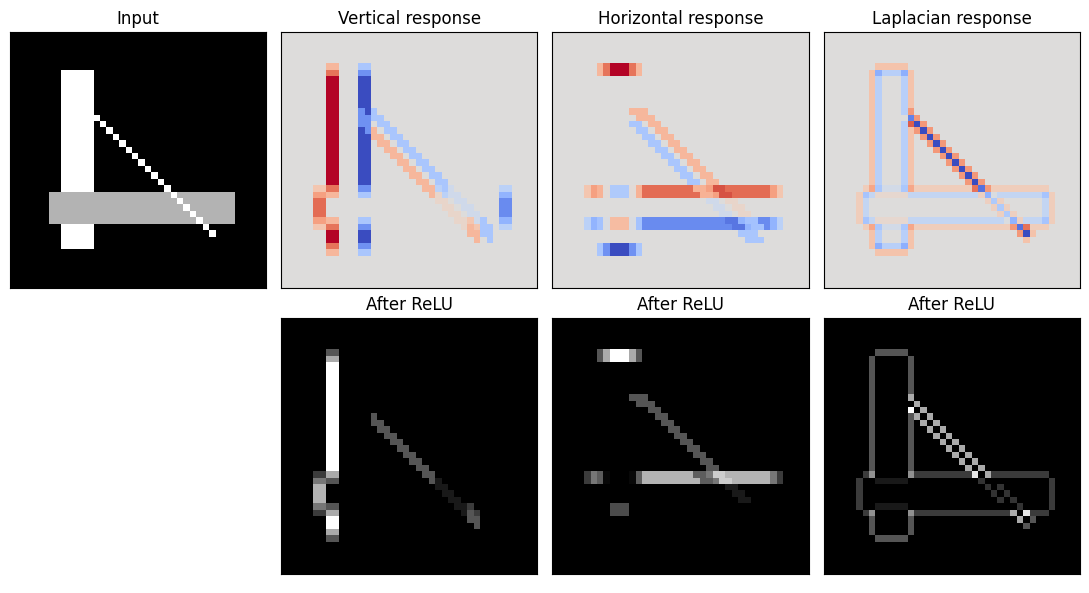

In [8]:
demo = torch.zeros(40, 40)
demo[6:34, 8:13] = 1.0
demo[25:30, 6:35] = 0.7
diagonal = torch.arange(8, 32)
demo[diagonal, diagonal] = 1.0

kernels = torch.tensor([
    [[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]],  # vertical edges
    [[-1., -1., -1.], [0., 0., 0.], [1., 1., 1.]],  # horizontal edges
    [[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]],    # Laplacian
])[:, None]

responses = F.conv2d(demo[None, None], kernels, padding=1)[0]
activated = F.relu(responses)

fig, axes = plt.subplots(2, 4, figsize=(11, 6))
axes[0, 0].imshow(demo); axes[0, 0].set_title("Input")
axes[1, 0].axis("off")
names = ["Vertical", "Horizontal", "Laplacian"]
for index, name in enumerate(names):
    limit = responses[index].abs().max().item()
    axes[0, index + 1].imshow(responses[index], cmap="coolwarm", vmin=-limit, vmax=limit)
    axes[0, index + 1].set_title(f"{name} response")
    axes[1, index + 1].imshow(activated[index])
    axes[1, index + 1].set_title("After ReLU")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


<a id="pooling"></a>
## 7. Pooling

Pooling summarizes each local window without learned weights.

- **Max pooling** retains the largest response in each window.
- **Average pooling** retains the mean response.

Pooling reduces spatial resolution and computation in later layers, but it also discards information. It can provide some robustness to small local shifts; it does **not** make a network fully translation invariant. Modern CNNs also commonly downsample with strided convolutions.


In [9]:
pool_input = torch.tensor([
    [1., 3., 2., 0.],
    [4., 6., 5., 1.],
    [0., 2., 8., 7.],
    [1., 3., 9., 4.],
])[None, None]

max_pooled = F.max_pool2d(pool_input, kernel_size=2, stride=2)
avg_pooled = F.avg_pool2d(pool_input, kernel_size=2, stride=2)

print("Input:\n", pool_input[0, 0])
print("\nMax pooled:\n", max_pooled[0, 0])
print("\nAverage pooled:\n", avg_pooled[0, 0])


Input:
 tensor([[1., 3., 2., 0.],
        [4., 6., 5., 1.],
        [0., 2., 8., 7.],
        [1., 3., 9., 4.]])

Max pooled:
 tensor([[6., 5.],
        [3., 9.]])

Average pooled:
 tensor([[3.5000, 2.0000],
        [1.5000, 7.0000]])


<a id="receptive-fields"></a>
## 8. Receptive fields

A unit's **receptive field** is the input region that can affect it. Stacking layers increases context. Two stride-1 3×3 convolutions have an effective 5×5 receptive field; three have 7×7.

For each layer, track receptive-field size $r$ and the input-space jump $j$ between neighboring outputs:

$$r_{new}=r+(k-1)d\,j, \qquad j_{new}=j\,s.$$

Start with $r=1$ and $j=1$. Padding changes boundary behavior and output size, but not this theoretical receptive-field size.


In [10]:
def receptive_field(layers):
    size, jump = 1, 1
    rows = []
    for index, (kernel, stride, dilation) in enumerate(layers, start=1):
        size += (kernel - 1) * dilation * jump
        jump *= stride
        rows.append((index, kernel, stride, dilation, size, jump))
    return rows

architecture = [(3, 1, 1), (2, 2, 1), (3, 1, 1), (3, 1, 1)]
print("layer | kernel | stride | dilation | receptive field | jump")
for row in receptive_field(architecture):
    print(f"{row[0]:>5} | {row[1]:>6} | {row[2]:>6} | {row[3]:>8} | {row[4]:>15} | {row[5]:>4}")


layer | kernel | stride | dilation | receptive field | jump
    1 |      3 |      1 |        1 |               3 |    1
    2 |      2 |      2 |        1 |               4 |    2
    3 |      3 |      1 |        1 |               8 |    2
    4 |      3 |      1 |        1 |              12 |    2


<a id="train-a-small-cnn"></a>
## 9. Train a small CNN

We will classify noisy **vertical**, **horizontal**, and **diagonal** bars. Generating the data locally keeps the notebook reproducible and focuses attention on CNN mechanics.

This is intentionally a teaching example rather than an accuracy benchmark. The train and test sets use different randomly generated images.


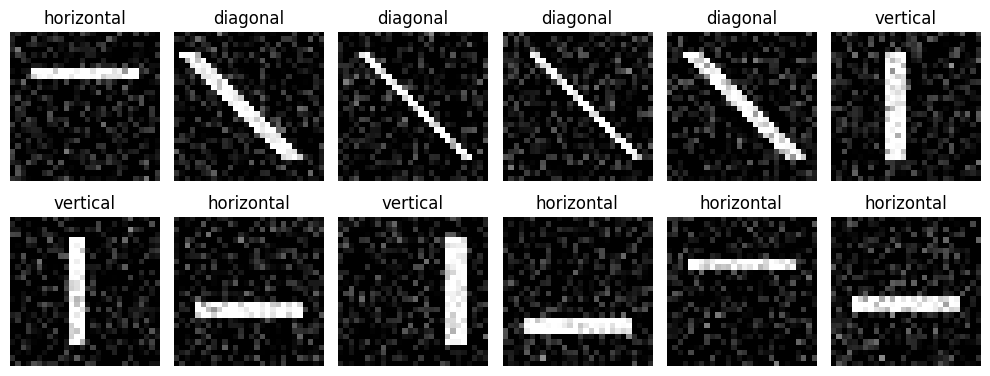

In [11]:
CLASS_NAMES = ["vertical", "horizontal", "diagonal"]

def make_shape_dataset(number_of_images, seed, image_size=28):
    generator = torch.Generator().manual_seed(seed)
    images = torch.zeros(number_of_images, 1, image_size, image_size)
    labels = torch.arange(number_of_images) % len(CLASS_NAMES)

    for index, label in enumerate(labels.tolist()):
        image = torch.zeros(image_size, image_size)
        thickness = int(torch.randint(2, 5, (1,), generator=generator))
        position = int(torch.randint(6, image_size - 6, (1,), generator=generator))

        if label == 0:  # vertical
            image[4:-4, position:position + thickness] = 1.0
        elif label == 1:  # horizontal
            image[position:position + thickness, 4:-4] = 1.0
        else:  # diagonal, with a small random offset
            offset = int(torch.randint(-3, 4, (1,), generator=generator))
            for row in range(4, image_size - 4):
                col = row + offset
                if 1 <= col < image_size - thickness:
                    image[row, col:col + thickness] = 1.0

        noise = 0.16 * torch.randn(image_size, image_size, generator=generator)
        images[index, 0] = (image + noise).clamp(0, 1)

    order = torch.randperm(number_of_images, generator=generator)
    return images[order], labels[order]

train_images, train_labels = make_shape_dataset(900, seed=SEED)
test_images, test_labels = make_shape_dataset(300, seed=SEED + 1)

train_loader = DataLoader(
    TensorDataset(train_images, train_labels),
    batch_size=64,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
test_loader = DataLoader(TensorDataset(test_images, test_labels), batch_size=128)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image_item, label in zip(axes.flat, train_images[:12], train_labels[:12]):
    ax.imshow(image_item[0], vmin=0, vmax=1)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [12]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(16, len(CLASS_NAMES))

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.global_pool(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

    def shape_trace(self, x):
        rows = [("input", tuple(x.shape))]
        x = F.relu(self.conv1(x)); rows.append(("conv1 + ReLU", tuple(x.shape)))
        x = self.pool(x); rows.append(("pool1", tuple(x.shape)))
        x = F.relu(self.conv2(x)); rows.append(("conv2 + ReLU", tuple(x.shape)))
        x = self.pool(x); rows.append(("pool2", tuple(x.shape)))
        x = self.global_pool(x); rows.append(("global average pool", tuple(x.shape)))
        x = torch.flatten(x, 1); rows.append(("flatten", tuple(x.shape)))
        x = self.classifier(x); rows.append(("class scores", tuple(x.shape)))
        return rows

model = TinyCNN().to(device)
for name, shape in model.shape_trace(torch.zeros(1, 1, 28, 28, device=device)):
    print(f"{name:<20} {shape}")
print("\nTrainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


input                (1, 1, 28, 28)
conv1 + ReLU         (1, 8, 28, 28)
pool1                (1, 8, 14, 14)
conv2 + ReLU         (1, 16, 14, 14)
pool2                (1, 16, 7, 7)
global average pool  (1, 16, 1, 1)
flatten              (1, 16)
class scores         (1, 3)

Trainable parameters: 1299


In [13]:
def evaluate(model, loader):
    model.eval()
    total_loss = total_correct = total_examples = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            total_loss += F.cross_entropy(logits, labels, reduction="sum").item()
            total_correct += (logits.argmax(1) == labels).sum().item()
            total_examples += labels.numel()
    return total_loss / total_examples, total_correct / total_examples

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
history = {"train_loss": [], "test_loss": [], "test_accuracy": []}

for epoch in range(1, 7):
    model.train()
    running_loss = examples_seen = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.numel()
        examples_seen += labels.numel()

    train_loss = running_loss / examples_seen
    test_loss, test_accuracy = evaluate(model, test_loader)
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_accuracy"].append(test_accuracy)
    print(f"epoch {epoch}: train loss={train_loss:.4f}, test loss={test_loss:.4f}, test accuracy={test_accuracy:.1%}")

assert history["test_accuracy"][-1] > 0.90, "The teaching model should easily solve this dataset."


epoch 1: train loss=1.0545, test loss=0.9557, test accuracy=33.3%
epoch 2: train loss=0.8265, test loss=0.5557, test accuracy=100.0%


epoch 3: train loss=0.3182, test loss=0.0973, test accuracy=100.0%
epoch 4: train loss=0.0415, test loss=0.0123, test accuracy=100.0%
epoch 5: train loss=0.0069, test loss=0.0043, test accuracy=100.0%


epoch 6: train loss=0.0032, test loss=0.0025, test accuracy=100.0%


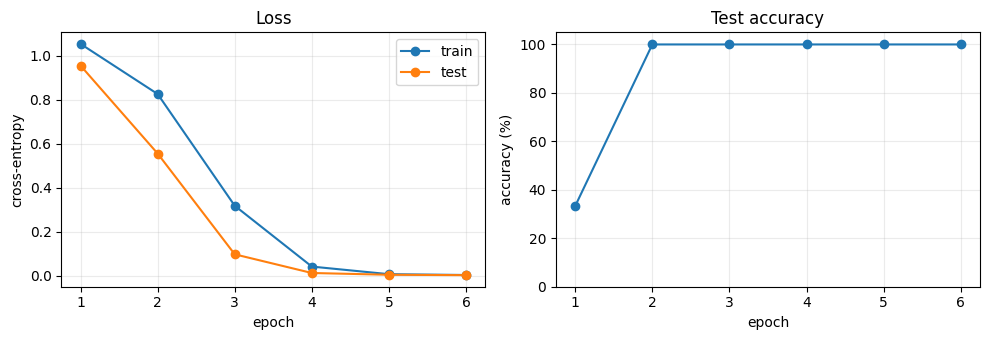

In [14]:
epochs = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["test_loss"], marker="o", label="test")
axes[0].set(xlabel="epoch", ylabel="cross-entropy", title="Loss")
axes[0].legend()
axes[1].plot(epochs, np.array(history["test_accuracy"]) * 100, marker="o")
axes[1].set(xlabel="epoch", ylabel="accuracy (%)", title="Test accuracy", ylim=(0, 105))
axes[0].grid(alpha=0.25); axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


<a id="inspect-learned-representations"></a>
## 10. Inspect learned representations

First-layer kernels can often be viewed directly because each has only one input channel. Feature maps show where each learned detector activates for a particular input. Later-layer channels are harder to interpret in isolation because they combine many earlier features.


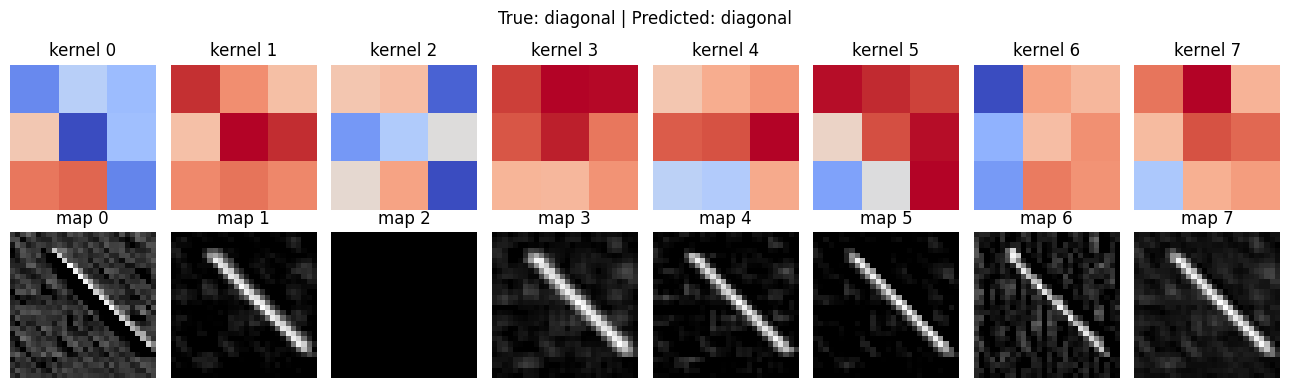

In [15]:
model.eval()
sample = test_images[0:1].to(device)
with torch.no_grad():
    first_features = F.relu(model.conv1(sample))[0].cpu()
    prediction = model(sample).argmax(1).item()

weights = model.conv1.weight.detach().cpu()[:, 0]
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for index in range(8):
    limit = weights[index].abs().max().item()
    axes[0, index].imshow(weights[index], cmap="coolwarm", vmin=-limit, vmax=limit)
    axes[0, index].set_title(f"kernel {index}")
    axes[1, index].imshow(first_features[index])
    axes[1, index].set_title(f"map {index}")
for ax in axes.flat:
    ax.axis("off")
fig.suptitle(f"True: {CLASS_NAMES[test_labels[0]]} | Predicted: {CLASS_NAMES[prediction]}")
plt.tight_layout()
plt.show()


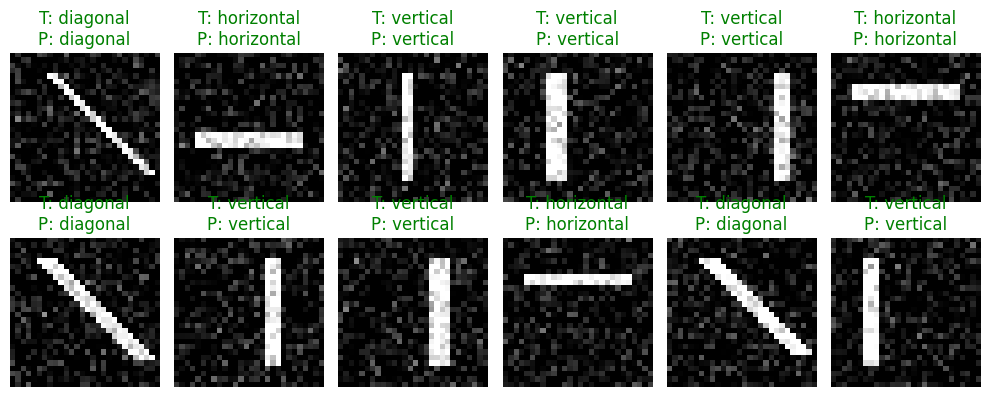

In [16]:
with torch.no_grad():
    predictions = model(test_images[:12].to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image_item, truth, predicted in zip(axes.flat, test_images[:12], test_labels[:12], predictions):
    correct = truth.item() == predicted.item()
    ax.imshow(image_item[0], vmin=0, vmax=1)
    ax.set_title(f"T: {CLASS_NAMES[truth]}\nP: {CLASS_NAMES[predicted]}", color="green" if correct else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()


<a id="efficient-convolutions"></a>
## 11. Efficient convolutions

### 11.1 The 1×1 convolution

At each spatial location, a 1×1 convolution mixes the channel vector using the **same learned matrix everywhere**:

$$y_{h,w}=Wx_{h,w}+b.$$

It can increase or decrease channel count while preserving height and width (for stride 1). It does not inspect neighboring pixels. The operation itself is affine, not nonlinear; it becomes part of a nonlinear transformation when followed by an activation.


In [17]:
pointwise = nn.Conv2d(3, 2, kernel_size=1, bias=False)
with torch.no_grad():
    pointwise.weight.copy_(torch.tensor([[[[1.]], [[0.]], [[-1.]]],
                                          [[[0.5]], [[0.5]], [[0.5]]]]))

pointwise_input = torch.tensor([[[[1., 2.], [3., 4.]],
                                  [[5., 6.], [7., 8.]],
                                  [[2., 1.], [0., 3.]]]])
pointwise_output = pointwise(pointwise_input)

location = pointwise_input[0, :, 0, 0]
weight_matrix = pointwise.weight[:, :, 0, 0]
torch.testing.assert_close(pointwise_output[0, :, 0, 0], weight_matrix @ location)

print("Channel vector at pixel (0, 0):", location.tolist())
print("Mixed output at that pixel:     ", pointwise_output[0, :, 0, 0].tolist())
print("Full output shape:", tuple(pointwise_output.shape))


Channel vector at pixel (0, 0): [1.0, 5.0, 2.0]
Mixed output at that pixel:      [-1.0, 4.0]
Full output shape: (1, 2, 2, 2)


### 11.2 Depthwise-separable convolution

A standard convolution jointly performs spatial filtering and channel mixing. A depthwise-separable convolution splits this into:

1. a $K\times K$ **depthwise convolution**, one spatial filter per input channel (`groups=C_in`);
2. a 1×1 **pointwise convolution** that mixes channels and creates $C_{out}$ outputs.

Ignoring biases, the parameter counts are:

| Operation | Parameters |
|---|---:|
| Standard convolution | $K^2C_{in}C_{out}$ |
| Depthwise + pointwise | $K^2C_{in}+C_{in}C_{out}$ |

This is a structural efficiency trade-off, not a guarantee of better accuracy or wall-clock speed on every device.


In [18]:
channels_in, channels_out, spatial_size = 32, 64, 28
standard = nn.Conv2d(channels_in, channels_out, kernel_size=3, padding=1, bias=False)
separable = nn.Sequential(
    nn.Conv2d(channels_in, channels_in, kernel_size=3, padding=1, groups=channels_in, bias=False),
    nn.Conv2d(channels_in, channels_out, kernel_size=1, bias=False),
)

example = torch.randn(1, channels_in, spatial_size, spatial_size)
standard_parameters = sum(p.numel() for p in standard.parameters())
separable_parameters = sum(p.numel() for p in separable.parameters())

print("Standard output: ", tuple(standard(example).shape))
print("Separable output:", tuple(separable(example).shape))
print(f"Standard parameters:  {standard_parameters:,}")
print(f"Separable parameters: {separable_parameters:,}")
print(f"Parameter reduction:  {standard_parameters / separable_parameters:.2f}×")


Standard output:  (1, 64, 28, 28)
Separable output: (1, 64, 28, 28)
Standard parameters:  18,432
Separable parameters: 2,336
Parameter reduction:  7.89×


<a id="mobilenetv2-inverted-residuals"></a>
## 12. MobileNetV2 inverted residuals

MobileNetV2 applies efficient operations in the sequence:

1. **expand** channels with a 1×1 convolution and ReLU6;
2. apply a 3×3 **depthwise** convolution and ReLU6;
3. **project** to a narrow output with a linear 1×1 convolution (no activation afterward);
4. add the input only when stride is 1 and input/output shapes match.

It is called an *inverted residual* because the skip connection joins narrow representations while spatial processing happens in an expanded representation. The last projection is a *linear bottleneck*: avoiding an activation there helps preserve information in the narrow space.


In [19]:
class InvertedResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, expansion_factor=6):
        super().__init__()
        if stride not in (1, 2):
            raise ValueError("stride must be 1 or 2")

        hidden_channels = int(round(in_channels * expansion_factor))
        layers = []
        if expansion_factor != 1:
            layers.extend([
                nn.Conv2d(in_channels, hidden_channels, 1, bias=False),
                nn.BatchNorm2d(hidden_channels),
                nn.ReLU6(inplace=True),
            ])
        else:
            hidden_channels = in_channels

        layers.extend([
            nn.Conv2d(hidden_channels, hidden_channels, 3, stride=stride,
                      padding=1, groups=hidden_channels, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),  # deliberately no activation here
        ])
        self.block = nn.Sequential(*layers)
        self.use_residual = stride == 1 and in_channels == out_channels

    def forward(self, x):
        transformed = self.block(x)
        return x + transformed if self.use_residual else transformed

same_shape_block = InvertedResidualBlock(16, 16, stride=1, expansion_factor=6)
downsample_block = InvertedResidualBlock(16, 24, stride=2, expansion_factor=6)
block_input = torch.randn(2, 16, 28, 28)

print("Residual block:", tuple(block_input.shape), "->", tuple(same_shape_block(block_input).shape),
      "skip =", same_shape_block.use_residual)
print("Downsample block:", tuple(block_input.shape), "->", tuple(downsample_block(block_input).shape),
      "skip =", downsample_block.use_residual)


Residual block: (2, 16, 28, 28) -> (2, 16, 28, 28) skip = True
Downsample block: (2, 16, 28, 28) -> (2, 24, 14, 14) skip = False


<a id="transposed-convolution"></a>
## 13. Transposed convolution

A transposed convolution is a learnable operation that can increase spatial resolution. It corresponds to the transpose of the linear map represented by a convolution (and appears when computing a convolution's gradient with respect to its input). Despite the common name “deconvolution,” it is **not generally the inverse of convolution**.

For one spatial dimension,

$$
\text{out}=(\text{in}-1)s-2p+d(k-1)+\text{output\_padding}+1.
$$

`output_padding` resolves output-shape ambiguity when stride is greater than 1; it does not literally append a border of zeros to the result.


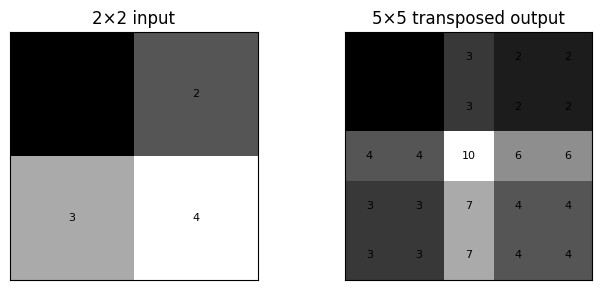

In [20]:
small_input = torch.tensor([[[[1., 2.], [3., 4.]]]])
transpose_layer = nn.ConvTranspose2d(1, 1, kernel_size=3, stride=2, bias=False)
with torch.no_grad():
    transpose_layer.weight.fill_(1.0)
expanded = transpose_layer(small_input)[0, 0]

predicted_size = (2 - 1) * 2 - 2 * 0 + 1 * (3 - 1) + 0 + 1
assert tuple(expanded.shape) == (predicted_size, predicted_size) == (5, 5)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, values, title in zip(axes, [small_input[0, 0], expanded], ["2×2 input", "5×5 transposed output"]):
    ax.imshow(values.detach())
    ax.set_title(title)
    for (row, col), value in np.ndenumerate(values.detach().numpy()):
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


### Uneven overlap and checkerboard artifacts

Each input value “paints” a kernel-shaped region into the output; overlapping contributions are summed. When the kernel size is not divisible by the stride, some output locations may receive more contributions than others. In learned image decoders this can contribute to checkerboard artifacts.

Common choices include carefully matched kernel/stride settings or explicit nearest/bilinear upsampling followed by a normal convolution. These are design options, not universally interchangeable fixes.


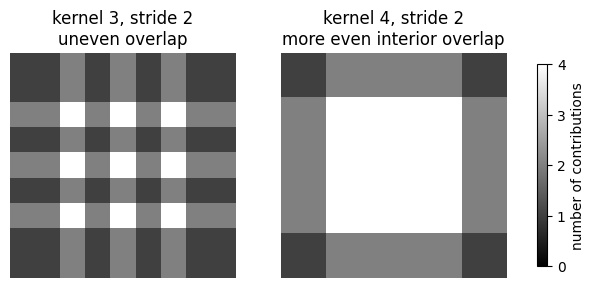

In [21]:
def overlap_map(kernel_size, stride=2):
    layer = nn.ConvTranspose2d(1, 1, kernel_size=kernel_size, stride=stride, bias=False)
    with torch.no_grad():
        layer.weight.fill_(1.0)
    return layer(torch.ones(1, 1, 4, 4))[0, 0].detach()

uneven = overlap_map(kernel_size=3)
even = overlap_map(kernel_size=4)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, values, title in zip(
    axes,
    [uneven, even],
    ["kernel 3, stride 2\nuneven overlap", "kernel 4, stride 2\nmore even interior overlap"],
):
    shown = ax.imshow(values, vmin=0, vmax=4)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(shown, ax=axes, shrink=0.75, label="number of contributions")
plt.show()


<a id="summary-and-exercises"></a>
## 14. Summary

| Concept | Changes spatial size? | Changes channels? | Learned weights? |
|---|---|---|---|
| Standard convolution | Possibly | Yes | Yes |
| ReLU | No | No | No |
| Pooling | Usually | No | No |
| 1×1 convolution | Only if stride > 1 | Yes | Yes |
| Depthwise convolution | Possibly | Normally no | Yes |
| Transposed convolution | Often increases it | Yes | Yes |

### Core reasoning checklist

For any CNN layer, ask:

1. What is the input layout and shape?
2. What local region does one output use?
3. How do stride, padding, and dilation change geometry?
4. How are channels combined?
5. How many parameters and approximate operations are required?
6. Where is non-linearity introduced?
7. How does this layer change the receptive field and information content?


## Exercises

1. **Geometry:** Find the output shape for input `(N=4, C=3, H=48, W=64)` after `Conv2d(3, 20, kernel_size=(5, 3), stride=(2, 1), padding=(2, 1))`.
2. **Parameters:** How many parameters does that layer have with bias?
3. **Implementation:** Extend `cross_correlation2d` to support padding and stride.
4. **Experiment:** Remove both pooling layers from `TinyCNN`. What must change? Compare accuracy, runtime, and parameter count.
5. **Representation:** Train with more noise or translated bars. Which feature maps remain interpretable?
6. **Efficiency:** Compare parameters and MACs for standard versus separable 3×3 convolutions when $C_{in}=C_{out}=128$.
7. **Upsampling:** Compare a transposed convolution with nearest-neighbor interpolation followed by `Conv2d`. Inspect their output shapes and overlap patterns.

<details>
<summary><strong>Hints and short answers</strong></summary>

1. Apply the geometry formula separately: the output is `(4, 20, 24, 64)`.
2. $20(3\times5\times3+1)=920$ parameters.
3. Pad with `F.pad`, then increment the loop indices by the stride.
4. Without pooling, the spatial shape stays 28×28 until global pooling, so no classifier change is required here. Computation increases; whether accuracy changes is empirical.
5. Look for maps responding to orientation rather than a fixed absolute location.
6. Standard: $128^2\times9=147{,}456$; separable: $128\times9+128^2=17{,}536$, about 8.41× fewer parameters.
7. Make both methods reach the same target size before comparing their values.
</details>


## Further reading

- [PyTorch `Conv2d` documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [PyTorch `ConvTranspose2d` documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)
- Sandler et al., [*MobileNetV2: Inverted Residuals and Linear Bottlenecks*](https://arxiv.org/abs/1801.04381)
- Odena, Dumoulin, and Olah, [*Deconvolution and Checkerboard Artifacts*](https://distill.pub/2016/deconv-checkerboard/)

A productive next step is to replace the synthetic data with Fashion-MNIST or CIFAR-10 and repeat the same workflow: predict shapes, train, inspect feature maps, and analyze mistakes.
